### Setup

In [1]:
import matplotlib.pyplot as plt
import scipy as sc
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os
import torch
from tqdm import tqdm

In [2]:
sys.path.insert(0, os.getcwd())

from model import GPTConfig, GPT
from lib.utils import get_batch

In [3]:
device='cpu'
dataset='shakespeare'
checkpoint_dir='ckpt_models'

### Identifiability

In [4]:
%%capture
torch.manual_seed(1337)

# load the checkpointed model state from last train save
ckpt_path = os.path.join(checkpoint_dir, 'ckpt_bpe.pt')
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])
model = GPT(gptconf)
state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)

model.eval() # disables dropout
model.to(device)

In [5]:
model.config.print()

sequence length: 256
head size: 64
embedding dimension: 256
number of heads:4


In [6]:
model.config.vocab_size

50304

$\newcommand{\A}{\mathbf{A}}$
$\newcommand{\T}{\mathbf{T}}$
$\newcommand{\E}{\mathbf{E}}$
$\newcommand{\H}{\mathbf{H}}$
$\newcommand{\W}{\mathbf{W}}$

Consider a GPT architecture with $\ell=4$ transformer blocks each consisting of a multihead attention ($d=256$, $n=256$, $h=4$) and a multi-layer perceptron. We train this model for $1000$ iterations with learning rate $\eta=0.001$ on an Intel MeteorLake (Gen12) GPU. 

Then we take $S=100$ samples from the testset, and then for each attention head in the first transformer block, we compute the SVD of attention matrix $\A$ and $\T=\E\W^V\H$ to obtain their conditioning number $\kappa=\sigma_\max/\sigma_\min$.




Can compare these results for GPT BPE token embeddings vs charcter-level embeddings

In [7]:
n = model.config.block_size
nh = model.config.n_head

In [8]:
X, Y = get_batch('eval', os.path.join('data', dataset), device, n, model.config.batch_size)
print(X.dtype)
print(X.min().item(), X.max().item())
print(model.config.vocab_size)

torch.int64
0 49928
50304


In [9]:
eval_iters = 100
df_rows = []
for i in tqdm(range(eval_iters)):
    row=dict()
    X, Y = get_batch('eval', os.path.join('data', dataset), device, n, model.config.batch_size) 
    for j in range(nh):
        A,T,v = model.get_matricies(X,j)

        # Is there a correlation between the conditioning numbers of v and T?
        _, S_T, _ = np.linalg.svd(T, full_matrices=False)
        _, S_v, _ = np.linalg.svd(v, full_matrices=False)
        _, S_A, _ = np.linalg.svd(A)
        row[f"cond_T_{j}"]= S_T[0] / S_T[-1]
        row[f"cond_v_{j}"]= S_v[0] / S_v[-1]
        row[f"cond_A_{j}"]= S_A[0] / S_A[-1]

        # Compare effective attention vs raw attention (Brunner et al. Section 3.4)
        T_aug = np.hstack([T, np.ones((T.shape[0],1))])
        basis_LN = sc.linalg.null_space(T_aug.T)
        A_null = A @ basis_LN @ basis_LN.T
        A_eff = A - A_null

        # fraction of attention weight in the null space
        null_component_norm = np.linalg.norm(A_null, 'fro')
        raw_norm = np.linalg.norm(A, 'fro')
        row[f"frac_null_{j}"]= null_component_norm / raw_norm

        # Does Pearson correlation between raw and effective attention decrease with sequence length?
        # would need to train models with different seq. len for this
        # pearsonr(A.flatten(), A_eff.flatten())
    
        # do these statistics change across transformer layers?
        
    df_rows.append(row)
    
df = pd.DataFrame(df_rows)

100%|██████████| 100/100 [04:14<00:00,  2.55s/it]


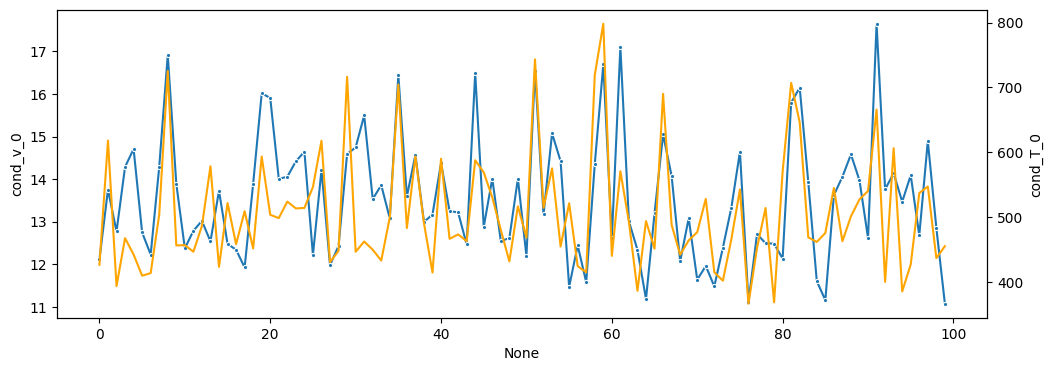

In [10]:
fig,ax = plt.subplots(1,1,figsize=(12,4))
sns.lineplot(df, x=df.index, y="cond_v_0", ax=ax, marker=".")
ax1 = ax.twinx()
sns.lineplot(df, x=df.index, y="cond_T_0", ax=ax1, color="orange")
plt.show()

In [11]:
pearsonr(df['cond_v_0'], df['cond_T_0'])

PearsonRResult(statistic=np.float32(0.6401108), pvalue=np.float32(7.481271e-13))

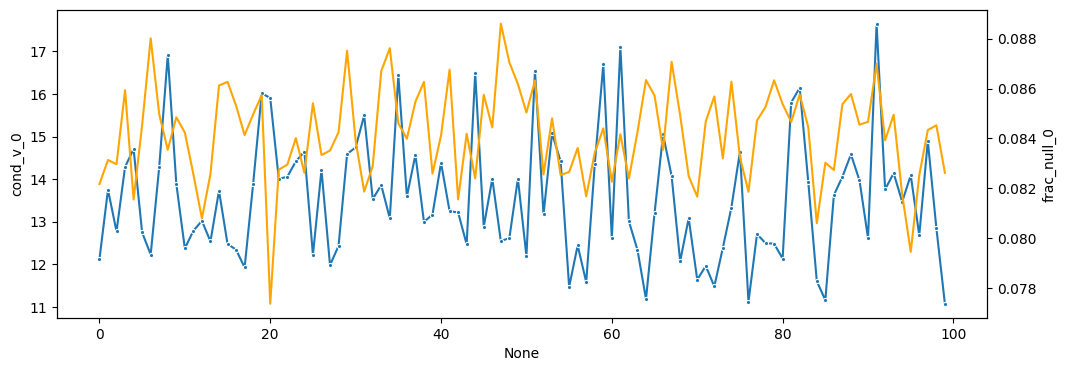

In [12]:
fig,ax = plt.subplots(1,1,figsize=(12,4))
sns.lineplot(df, x=df.index, y="cond_v_0", ax=ax, marker=".")
ax1 = ax.twinx()
sns.lineplot(df, x=df.index, y="frac_null_0", ax=ax1, color="orange")
plt.show()